In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
_URL = "http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz"

path_to_zip = tf.keras.utils.get_file(
    "facades.tar.gz",
    origin=_URL,
    extract=True
)

print(path_to_zip)

/root/.keras/datasets/facades_extracted


In [ ]:
import os

dataset_path = os.path.join(
    path_to_zip,
    "facades"
)

print(dataset_path)
print(os.listdir(dataset_path))

/root/.keras/datasets/facades_extracted/facades
['test', 'val', 'train']


In [ ]:
import os

train_path = os.path.join(dataset_path, "train")

train_files = os.listdir(train_path)

print("Number of training images:", len(train_files))
print("First image:", train_files[0])

Number of training images: 400
First image: 152.jpg


Image shape: (256, 512, 3)


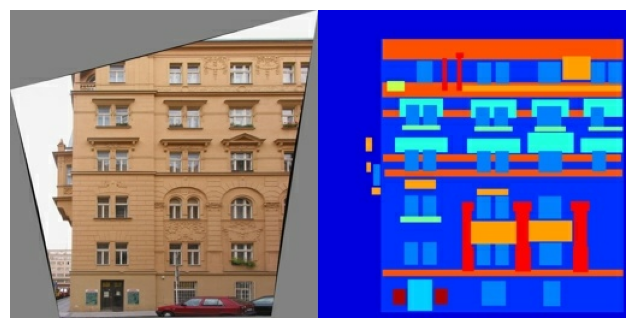

In [ ]:
sample_path = os.path.join(train_path, train_files[0])

image = tf.io.read_file(sample_path)
image = tf.image.decode_jpeg(image)

print("Image shape:", image.shape)

plt.figure(figsize=(8, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
IMG_WIDTH = 256
IMG_HEIGHT = 256

def load_image(image_file):
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image)

    w = tf.shape(image)[1]
    w = w // 2

    input_image = image[:, :w, :]
    target_image = image[:, w:, :]

    input_image = tf.cast(input_image, tf.float32)
    target_image = tf.cast(target_image, tf.float32)

    return input_image, target_image

In [ ]:
def resize_and_normalize(input_image, target_image):
    input_image = tf.image.resize(
        input_image, [IMG_HEIGHT, IMG_WIDTH]
    )

    target_image = tf.image.resize(
        target_image, [IMG_HEIGHT, IMG_WIDTH]
    )

    input_image = (input_image / 127.5) - 1
    target_image = (target_image / 127.5) - 1

    return input_image, target_image

In [ ]:
input_image, target_image = load_image(sample_path)

input_image, target_image = resize_and_normalize(
    input_image, target_image
)

print("Input shape:", input_image.shape)
print("Target shape:", target_image.shape)
print("Input range:", tf.reduce_min(input_image).numpy(),
      "to", tf.reduce_max(input_image).numpy())

Input shape: (256, 256, 3)
Target shape: (256, 256, 3)
Input range: -1.0 to 1.0


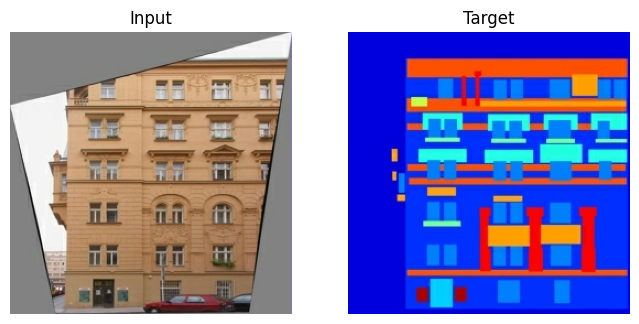

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow((input_image + 1) / 2)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow((target_image + 1) / 2)
plt.title("Target")
plt.axis("off")

plt.show()

In [ ]:
print("Input min/max:",
      tf.reduce_min(input_image).numpy(),
      tf.reduce_max(input_image).numpy())

print("Target min/max:",
      tf.reduce_min(target_image).numpy(),
      tf.reduce_max(target_image).numpy())

Input min/max: -1.0 1.0
Target min/max: -1.0 1.0


In [ ]:
def load_and_preprocess_image(image_file):
    input_image, target_image = load_image(image_file)
    input_image, target_image = resize_and_normalize(
        input_image, target_image
    )
    return input_image, target_image

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    [os.path.join(train_path, f) for f in train_files]
)

train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Training dataset prepared.")

Training dataset prepared.


In [ ]:
BUFFER_SIZE = 400
BATCH_SIZE = 1

train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Training dataset prepared successfully.")

Training dataset prepared successfully.


In [ ]:
for inp, tar in train_dataset.take(1):
    print("Input batch shape:", inp.shape)
    print("Target batch shape:", tar.shape)

Input batch shape: (1, 256, 256, 3)
Target batch shape: (1, 256, 256, 3)


In [ ]:
train_dataset = train_dataset.unbatch()

for inp, tar in train_dataset.take(1):
    print("After unbatch:")
    print(inp.shape)
    print(tar.shape)

After unbatch:
(256, 256, 3)
(256, 256, 3)


In [ ]:
OUTPUT_CHANNELS = 3

def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()

    result.add(
        tf.keras.layers.Conv2D(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    result.add(tf.keras.layers.LeakyReLU())

    return result

In [ ]:
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)

    result = tf.keras.Sequential()

    result.add(
        tf.keras.layers.Conv2DTranspose(
            filters,
            size,
            strides=2,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    result.add(tf.keras.layers.BatchNormalization())

    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))

    result.add(tf.keras.layers.ReLU())

    return result

In [ ]:
def Generator():
    inputs = tf.keras.layers.Input(
        shape=[256, 256, 3]
    )

    # Encoder
    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4),
        downsample(256, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
        downsample(512, 4),
    ]

    # Decoder
    up_stack = [
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4, apply_dropout=True),
        upsample(512, 4),
        upsample(256, 4),
        upsample(128, 4),
        upsample(64, 4),
    ]

    x = inputs
    skips = []

    # Encoder
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    # Decoder + skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    # Final layer
    initializer = tf.random_normal_initializer(0., 0.02)

    last = tf.keras.layers.Conv2DTranspose(
        OUTPUT_CHANNELS,
        4,
        strides=2,
        padding="same",
        kernel_initializer=initializer,
        activation="tanh"
    )

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

In [ ]:
generator=Generator()
generator.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_15       │ (None, 128, 128,  │      3,072 │ input_layer_9[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_16       │ (None, 64, 64,    │    131,584 │ sequential_15[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_17       │ (None, 32, 32,    │    525,312 │ sequential_16[0]… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_18       │ (None, 16, 16,    │  2,099,200 │ sequential_17[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_19       │ (None, 8, 8, 512) │  4,196,352 │ sequential_18[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_20       │ (None, 4, 4, 512) │  4,196,352 │ sequential_19[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_21       │ (None, 2, 2, 512) │  4,196,352 │ sequential_20[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_22       │ (None, 1, 1, 512) │  4,196,352 │ sequential_21[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_23       │ (None, 2, 2, 512) │  4,196,352 │ sequential_22[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 2,      │          0 │ sequential_23[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_24       │ (None, 4, 4, 512) │  8,390,656 │ concatenate[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4, 4,      │          0 │ sequential_24[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_20[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_25       │ (None, 8, 8, 512) │  8,390,656 │ concatenate_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8,      │          0 │ sequential_25[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_26       │ (None, 16, 16,    │  8,390,656 │ concatenate_2[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ sequential_26[0]

 Total params: 54,425,859 (207.62 MB)

 Trainable params: 54,414,979 (207.58 MB)

 Non-trainable params: 10,880 (42.50 KB)

In [ ]:
train_dataset = train_dataset.batch(1)

for inp, tar in train_dataset.take(1):
    print("Input shape:", inp.shape)
    print("Target shape:", tar.shape)

Input shape: (1, 256, 256, 3)
Target shape: (1, 256, 256, 3)


In [ ]:
for inp, tar in train_dataset.take(1):
    generated_image = generator(inp)

    print("Input shape:", inp.shape)
    print("Generated image shape:", generated_image.shape)

Input shape: (1, 256, 256, 3)
Generated image shape: (1, 256, 256, 3)


In [ ]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = tf.keras.layers.Input(
        shape=[256, 256, 3],
        name="input_image"
    )

    tar = tf.keras.layers.Input(
        shape=[256, 256, 3],
        name="target_image"
    )

    x = tf.keras.layers.concatenate([inp, tar])

    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)

    conv = tf.keras.layers.Conv2D(
        512,
        4,
        strides=1,
        kernel_initializer=initializer,
        use_bias=False
    )(zero_pad1)

    batchnorm = tf.keras.layers.BatchNormalization()(conv)
    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)

    last = tf.keras.layers.Conv2D(
        1,
        4,
        strides=1,
        kernel_initializer=initializer
    )(zero_pad2)

    return tf.keras.Model(
        inputs=[inp, tar],
        outputs=last
    )

In [ ]:
discriminator=Discriminator()
discriminator.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_image        │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 256, 256,  │          0 │ input_image[0][0… │
│ (Concatenate)       │ 6)                │            │ target_image[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_30       │ (None, 128, 128,  │      6,144 │ concatenate_7[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_31       │ (None, 64, 64,    │    131,584 │ sequential_30[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_32       │ (None, 32, 32,    │    525,312 │ sequential_31[0]… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 34, 34,    │          0 │ sequential_32[0]… │
│ (ZeroPadding2D)     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 31, 31,    │  2,097,152 │ zero_padding2d[0… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │      2,048 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_19      │ (None, 31, 31,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 33, 33,    │          0 │ leaky_re_lu_19[0… │
│ (ZeroPadding2D)     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 30, 30, 1) │      8,193 │ zero_padding2d_1… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,770,433 (10.57 MB)

 Trainable params: 2,768,641 (10.56 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
for inp, tar in train_dataset.take(1):
    disc_output = discriminator([inp, tar])

    print("Input shape:", inp.shape)
    print("Target shape:", tar.shape)
    print("Discriminator output shape:", disc_output.shape)

Input shape: (1, 256, 256, 3)
Target shape: (1, 256, 256, 3)
Discriminator output shape: (1, 30, 30, 1)


In [ ]:
loss_object = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(
        tf.ones_like(disc_generated_output),
        disc_generated_output
    )

    l1_loss = tf.reduce_mean(
        tf.abs(target - gen_output)
    )

    total_gen_loss = gan_loss + (100 * l1_loss)

    return total_gen_loss, gan_loss, l1_loss


def discriminator_loss(
    disc_real_output,
    disc_generated_output
):
    real_loss = loss_object(
        tf.ones_like(disc_real_output),
        disc_real_output
    )

    generated_loss = loss_object(
        tf.zeros_like(disc_generated_output),
        disc_generated_output
    )

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(
    2e-4,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    2e-4,
    beta_1=0.5
)

print("Optimizers ready!")

Optimizers ready!


In [ ]:
@tf.function
def train_step(input_image, target):
    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # Generate fake image
        gen_output = generator(input_image, training=True)

        # Discriminator predictions
        disc_real_output = discriminator(
            [input_image, target],
            training=True
        )

        disc_generated_output = discriminator(
            [input_image, gen_output],
            training=True
        )

        # Calculate losses
        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(
            disc_generated_output,
            gen_output,
            target
        )

        disc_loss = discriminator_loss(
            disc_real_output,
            disc_generated_output
        )

    # Calculate gradients
    generator_gradients = gen_tape.gradient(
        gen_total_loss,
        generator.trainable_variables
    )

    discriminator_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update model weights
    generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    return (
        gen_total_loss,
        gen_gan_loss,
        gen_l1_loss,
        disc_loss
    )

In [ ]:
for input_image, target in train_dataset.take(1):

    losses = train_step(input_image, target)

    print("Generator Total Loss:", losses[0].numpy())
    print("Generator GAN Loss:", losses[1].numpy())
    print("Generator L1 Loss:", losses[2].numpy())
    print("Discriminator Loss:", losses[3].numpy())

Generator Total Loss: 74.50468
Generator GAN Loss: 1.4293066
Generator L1 Loss: 0.7307537
Discriminator Loss: 1.9153324


In [ ]:
EPOCHS=20
print("Epochs:",EPOCHS)

Epochs: 20


In [ ]:
checkpoint = tf.train.Checkpoint(
    generator=generator,
    discriminator=discriminator,
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer
)

checkpoint_manager = tf.train.CheckpointManager(
    checkpoint,
    "./pix2pix_checkpoints",
    max_to_keep=5
)

print("Checkpoint system ready!")

Checkpoint system ready!


In [ ]:
import time

EPOCHS = 10

for epoch in range(EPOCHS):
    start = time.time()

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    for step, (input_image, target) in enumerate(train_dataset):
        gen_total_loss, gen_gan_loss, gen_l1_loss, disc_loss = train_step(
            input_image,
            target
        )

        if (step + 1) % 50 == 0:
            print(
                f"Step {step + 1}: "
                f"Gen Loss = {gen_total_loss:.4f}, "
                f"Disc Loss = {disc_loss:.4f}"
            )

    # Save checkpoint after every epoch
    checkpoint_path = checkpoint_manager.save()

    print(
        f"Epoch {epoch + 1} completed in "
        f"{time.time() - start:.2f} sec"
    )
    print("Checkpoint saved:", checkpoint_path)


Epoch 1/10
Step 50: Gen Loss = 64.3127, Disc Loss = 0.1638
Step 100: Gen Loss = 47.0661, Disc Loss = 0.1441
Step 150: Gen Loss = 44.4856, Disc Loss = 0.7815
Step 200: Gen Loss = 46.0892, Disc Loss = 0.1739
Step 250: Gen Loss = 41.5011, Disc Loss = 0.1577
Step 300: Gen Loss = 41.0118, Disc Loss = 0.1940
Step 350: Gen Loss = 33.6271, Disc Loss = 0.1970
Step 400: Gen Loss = 45.4975, Disc Loss = 0.3013
Epoch 1 completed in 1199.81 sec
Checkpoint saved: ./pix2pix_checkpoints/ckpt-1

Epoch 2/10
Step 50: Gen Loss = 57.8123, Disc Loss = 0.0738
Step 100: Gen Loss = 34.4431, Disc Loss = 0.2322
Step 150: Gen Loss = 30.2464, Disc Loss = 0.7248
Step 200: Gen Loss = 64.3461, Disc Loss = 0.1412
Step 250: Gen Loss = 28.0904, Disc Loss = 0.4658
Step 300: Gen Loss = 60.2783, Disc Loss = 0.0995
Step 350: Gen Loss = 37.7702, Disc Loss = 0.1589
Step 400: Gen Loss = 32.4978, Disc Loss = 0.8236
Epoch 2 completed in 1182.26 sec
Checkpoint saved: ./pix2pix_checkpoints/ckpt-2

Epoch 3/10
Step 50: Gen Loss = 42

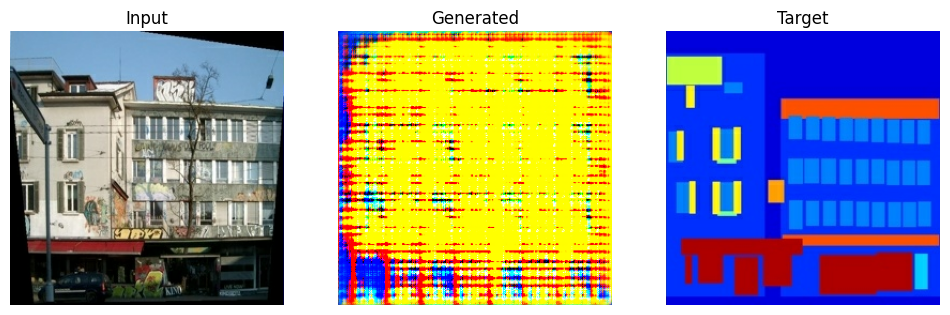

In [ ]:
for input_image, target in train_dataset.take(1):
    prediction = generator(input_image, training=False)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow((input_image[0] + 1) / 2)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow((prediction[0] + 1) / 2)
    plt.title("Generated")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow((target[0] + 1) / 2)
    plt.title("Target")
    plt.axis("off")

    plt.show()

In [ ]:
import os

backup_path = "/content/drive/MyDrive/Prodigy_Task4_Pix2Pix_Checkpoints"

print("Backup folder exists:", os.path.exists(backup_path))

if os.path.exists(backup_path):
    print("Files in backup:")
    print(os.listdir(backup_path))

Backup folder exists: True
Files in backup:
['ckpt-10.data-00000-of-00001', 'checkpoint', 'ckpt-8.data-00000-of-00001', 'ckpt-8.index', 'ckpt-6.index', 'ckpt-6.data-00000-of-00001', 'ckpt-7.data-00000-of-00001', 'ckpt-9.index', 'ckpt-10.index', 'ckpt-9.data-00000-of-00001', 'ckpt-7.index']


In [ ]:
checkpoint.restore(checkpoint_manager.latest_checkpoint)

print("Restored checkpoint:", checkpoint_manager.latest_checkpoint)

Restored checkpoint: ./pix2pix_checkpoints/ckpt-11


In [ ]:
import os

save_path = "/content/drive/MyDrive/Prodigy_Task4_Pix2Pix"

os.makedirs(save_path, exist_ok=True)

print("Folder exists:", os.path.exists(save_path))

Folder exists: True


In [ ]:
discriminator.save(
    "/content/drive/MyDrive/Prodigy_Task4_Pix2Pix/discriminator.keras"
)

print("Discriminator saved successfully!")

Discriminator saved successfully!


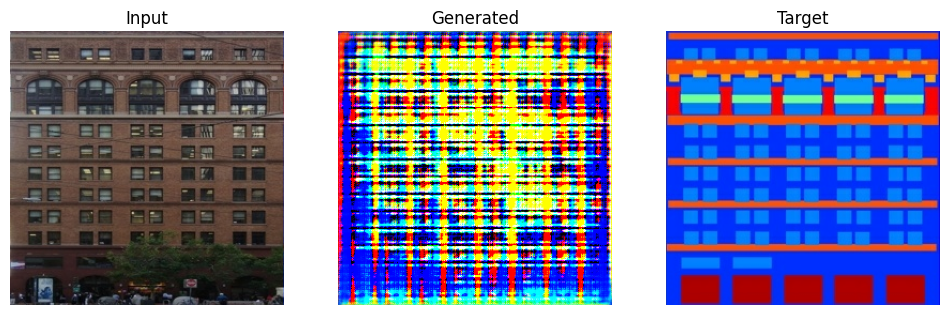

Final result saved successfully!


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs(
    "/content/drive/MyDrive/Prodigy_Task4_Pix2Pix/results",
    exist_ok=True
)

for input_image, target in train_dataset.take(1):
    prediction = generator(input_image, training=False)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow((input_image[0] + 1) / 2)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow((prediction[0] + 1) / 2)
    plt.title("Generated")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow((target[0] + 1) / 2)
    plt.title("Target")
    plt.axis("off")

    plt.savefig(
        "/content/drive/MyDrive/Prodigy_Task4_Pix2Pix/results/final_result.png",
        bbox_inches="tight"
    )

    plt.show()

print("Final result saved successfully!")